# Clustering Visualization
Visualize feature-space clustering on a point cloud to inspect which points
a `ClusteringTrimmer` would discard (large clusters = geometrically common regions).

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

from synthetic import SyntheticExperiment
from trimmer import ClusteringTrimmer
from feature_extractor import GeometricFeatureExtractor, zscored_features
from visualization import PointCloudVisualizer

## Configuration

In [2]:
N_SEEDS = 4
N_POINTS = 5000
MIN_CLUSTER_FRACTION = 0.05
K_NEIGHBORS = 10   # GeometricFeatureExtractor k

## Run clustering for each seed

In [3]:
fe = GeometricFeatureExtractor(k=K_NEIGHBORS)
trimmer = ClusteringTrimmer(fe, DBSCAN(), min_cluster_fraction=MIN_CLUSTER_FRACTION)

results = []
for seed in range(N_SEEDS):
    exp = SyntheticExperiment.generate(n=N_POINTS, noise_std=0, t_scale=8.0, seed=seed, style='2d-lattice')
    cloud = exp.P

    features = zscored_features(fe, cloud, cloud)[0]
    d = features.shape[1]
    eps = (2 * d) ** 0.5 * 0.2
    min_samples = int(np.log(len(cloud)))

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(features)
    labels = dbscan.labels_

    large_labels = trimmer._large_cluster_labels(labels, len(cloud))
    n_kept = (~np.isin(labels, list(large_labels))).sum()
    print(f'Seed {seed}: {np.unique(labels[labels >= 0]).size} clusters, {n_kept}/{len(cloud)} kept')

    results.append((cloud, labels, large_labels))

Seed 0: 4 clusters, 416/4970 kept
Seed 1: 4 clusters, 416/4970 kept
Seed 2: 4 clusters, 416/4970 kept
Seed 3: 4 clusters, 416/4970 kept


## Plots — cluster coloring (left) and trimmer result (right) per seed

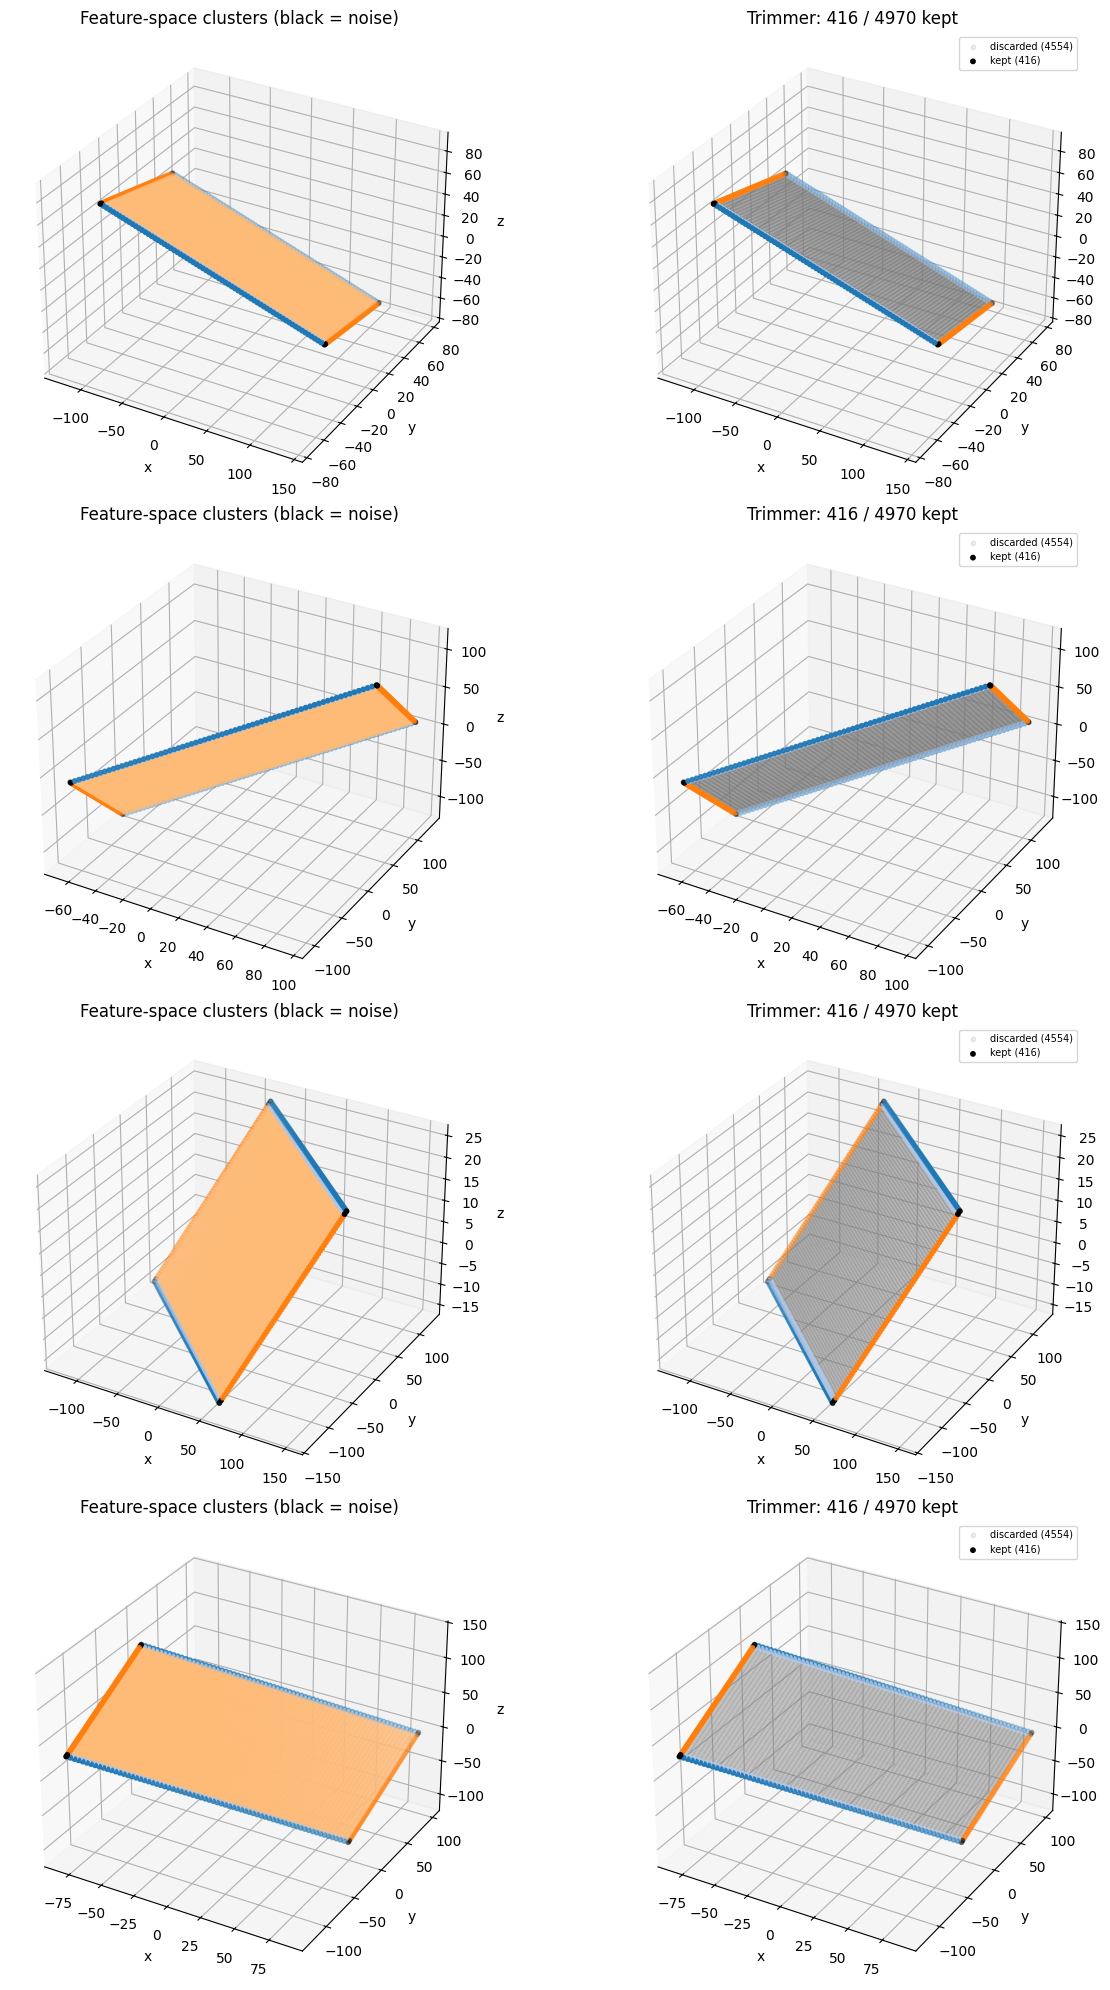

In [6]:
fig = plt.figure(figsize=(14, 5 * N_SEEDS))
for i, (cloud, labels, large_labels) in enumerate(results):
    ax_clusters = fig.add_subplot(N_SEEDS, 2, 2 * i + 1, projection='3d')
    ax_trimmer  = fig.add_subplot(N_SEEDS, 2, 2 * i + 2, projection='3d')

    ax_clusters.set_title(f'Seed {i} — feature-space clusters (black = noise)')
    PointCloudVisualizer.plot_cluster_coloring(ax_clusters, cloud, labels)

    ax_trimmer.set_title(f'Seed {i} — trimmer result (gray = discarded)')
    PointCloudVisualizer.plot_trimmer_result(ax_trimmer, cloud, labels, large_labels)

plt.tight_layout()
plt.savefig('../results/11_clustering_visualization.png', dpi=300)
plt.show()